# Load libraries

In [12]:
import sys
sys.path.insert(0, '/Users/svijaysh/NPP+DCfork/H2Integrate')

import numpy as np
import pandas as pd
from h2integrate.core.h2integrate_model import H2IntegrateModel



# Setup H2I model with nuclear + DC yaml file

In [17]:
h2i = H2IntegrateModel("examples/32_nuclear_DC_case_1/nuclear_datacenter_config.yaml")
h2i.setup()

In [18]:
system_capacity = h2i.prob.get_val("plant.nuclear.QuinnNuclearPerformanceModel.system_capacity", units="kW")
print(f"System capacity: {system_capacity[0]:.2f} kW")

System capacity: 1000000.00 kW


## The current setup is:

NPP is connected to he grid (selling all its power to the grid at 0.05/kwh)
The DC buys power from the grid. 

In [19]:

results = []

for capacity_mw in [500, 750, 1000, 1250, 1500]:
    capacity_kw = capacity_mw * 1000

    h2i.prob.set_val("nuclear.system_capacity",  capacity_kw, units="kW")
    h2i.prob.set_val("grid.interconnection_size", capacity_kw, units="kW")
    h2i.prob.set_val("nuclear.electricity_demand", np.full(8760, capacity_kw), units="kW")
    h2i.prob.set_val("grid.electricity_demand",    np.full(8760, 500_000),    units="kW")

    h2i.run()

    def get(path, units=None):
        v = h2i.prob.get_val(path, units=units) if units else h2i.prob.get_val(path)
        return float(v.flat[0]) if hasattr(v, 'flat') else v

    # ── Performance ──────────────────────────────────────────────────────────
    annual_gwh = get("nuclear.total_electricity_produced", "kW*h") / 1e6

    # ── Raw costs (2024 $, before cost-year adjustment) ───────────────────────
    nuc_capex_b      = get("nuclear.CapEx",      "USD")    / 1e9
    nuc_opex_m       = get("nuclear.OpEx",       "USD/year") / 1e6
    nuc_varopex_m    = get("nuclear.VarOpEx",    "USD/year") / 1e6

    # Grid raw costs tracked separately (not included in LCOE — see finance_subgroups in plant_config)
    grid_capex_m     = get("grid.CapEx",         "USD")    / 1e6
    grid_opex_m      = get("grid.OpEx",          "USD/year") / 1e6
    grid_revenue_m   = -get("grid.VarOpEx",      "USD/year") / 1e6  # negative → revenue

 

    # ── ProFAST financial metrics ─────────────────────────────────────────────
    lcoe_mwh  = get("finance_subgroup_nuclear.LCOE", "USD/(kW*h)") * 1000
    wacc_pct  = get("finance_subgroup_nuclear.wacc_electricity",                   "percent") * 100
    crf_pct   = get("finance_subgroup_nuclear.crf_electricity",                    "percent") * 100
    irr_pct   = get("finance_subgroup_nuclear.irr_electricity",                    "percent") * 100
    pi        = get("finance_subgroup_nuclear.profit_index_electricity",           "unitless")
    payback   = get("finance_subgroup_nuclear.investor_payback_period_electricity","yr")

    lcoe_breakdown = h2i.prob.get_val("finance_subgroup_nuclear.LCOE_breakdown")

    results.append({
        # config
        "nuclear_mw":          capacity_mw,
        # performance
        "capacity_factor":     get("nuclear.capacity_factor"),
        "annual_elec_gwh":     annual_gwh,
        # raw costs (not in LCOE for grid)
        "nuc_capex_B$":        nuc_capex_b,
        "nuc_opex_M$/yr":      nuc_opex_m,
        "nuc_varopex_M$/yr":   nuc_varopex_m,
        "grid_capex_M$":       grid_capex_m,
        "grid_opex_M$/yr":     grid_opex_m,
        "grid_revenue_M$/yr":  grid_revenue_m,
      
        # ProFAST metrics
        "lcoe_$/MWh":          lcoe_mwh,
        "wacc_%":              wacc_pct,
        "crf_%":               crf_pct,
        "irr_%":               irr_pct,
        "profit_index":        pi,
        "payback_yr":          payback,
        # full LCOE breakdown dict (one per row)
        "lcoe_breakdown":      lcoe_breakdown,
    })

df = pd.DataFrame(results)
print(df[["nuclear_mw","lcoe_$/MWh","wacc_%","crf_%","irr_%","profit_index","payback_yr"]].to_string(index=False))


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_

 nuclear_mw  lcoe_$/MWh  wacc_%    crf_%  irr_%  profit_index  payback_yr
        500  149.472482  5.6925 6.483406    6.0      2.989676        15.0
        750  135.424896  5.6925 6.483406    6.0      2.990466        15.0
       1000  126.444953  5.6925 6.483406    6.0      2.991087        15.0
       1250  119.994145  5.6925 6.483406    6.0      2.991608        15.0
       1500  115.034768  5.6925 6.483406    6.0      2.992060        15.0


In [21]:
df["lcoe_breakdown"][0]

{'LCOE: nuclear CapEx ($/kWh)': 0.10651008665490075,
 'LCOE: nuclear OpEx ($/kWh)': 0.0,
 'LCOE: nuclear Feedstock ($/kWh)': 0.026650803093396798,
 'LCOE: Taxes ($/kWh)': 0.014416892672562558,
 'LCOE: Finances ($/kWh)': 0.001894699188699143,
 'LCOE: Total ($/kWh)': 0.14947248160955923}

In [22]:

breakdown_rows = []
for _, row in df.iterrows():
    d = {"nuclear_mw": row["nuclear_mw"]}
    for k, v in row["lcoe_breakdown"].items():
        # Simplify key: strip "LCOE: " prefix and "($/kWh)" suffix
        short = k.replace("LCOE: ", "").replace(" ($/kWh)", "").strip()
        d[short] = v * 1000  # convert $/kWh - $/MWh
    breakdown_rows.append(d)

df_breakdown = pd.DataFrame(breakdown_rows).set_index("nuclear_mw")
print("LCOE breakdown ($/MWh):")
print(df_breakdown.to_string())


LCOE breakdown ($/MWh):
            nuclear CapEx  nuclear OpEx  nuclear Feedstock      Taxes  Finances       Total
nuclear_mw                                                                                 
500            106.510087           0.0          26.650803  14.416893  1.894699  149.472482
750             94.325641           0.0          26.650803  12.770757  1.677695  135.424896
1000            86.536714           0.0          26.650803  11.718462  1.538974  126.444953
1250            80.941481           0.0          26.650803  10.962538  1.439323  119.994145
1500            76.639869           0.0          26.650803  10.381384  1.362711  115.034768


In [23]:
.34 * 38

12.920000000000002

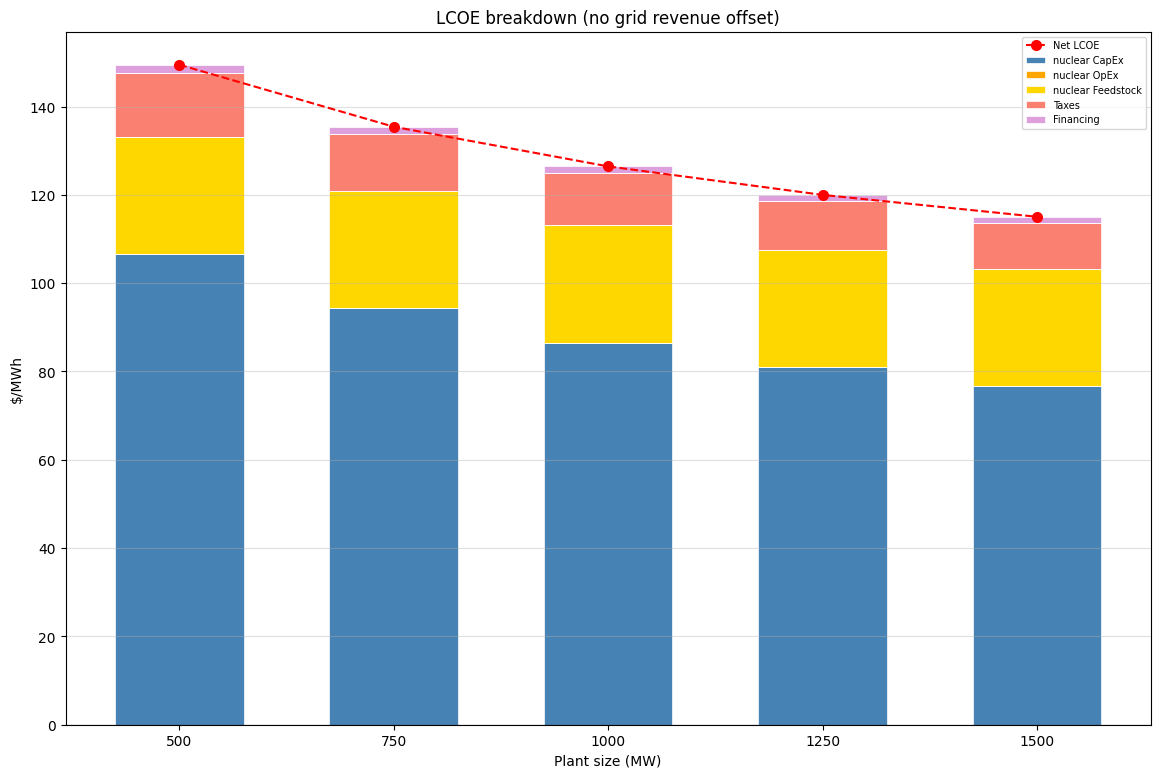

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 1, figsize=(14, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.35)

sizes  = df["nuclear_mw"].values.astype(float)
labels = [f"{int(s)}" for s in sizes]
x = np.arange(len(sizes))

# -- LCOE breakdown --
ax = axes
cols_colors = []
for col in df_breakdown.columns:
    if "Total" in col:
        continue
    elif "CapEx" in col and "nuclear" in col.lower():
        cols_colors.append((col, "steelblue", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "OpEx" in col and "nuclear" in col.lower():
        cols_colors.append((col, "orange", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "Feedstock" in col:
        cols_colors.append((col, "gold", col.replace("LCOE: ","").replace(" ($/kWh)","")))
    elif "Tax" in col:
        cols_colors.append((col, "salmon", "Taxes"))
    elif "Financ" in col:
        cols_colors.append((col, "plum", "Financing"))

bottom = np.zeros(len(df_breakdown))
for col, color, label in cols_colors:
    vals = df_breakdown[col].values.astype(float)
    pos = np.clip(vals, 0, None)
    neg = np.clip(vals, None, 0)
    ax.bar(x, pos, 0.6, bottom=bottom,        color=color, label=label, edgecolor="white", lw=0.5)
    ax.bar(x, neg, 0.6, bottom=bottom,        color=color, edgecolor="white", lw=0.5)
    bottom = np.where(vals >= 0, bottom + vals, bottom)

ax.plot(x, df["lcoe_$/MWh"].values, "ro--", ms=7, label="Net LCOE")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Plant size (MW)")
ax.set_ylabel("$/MWh")
ax.set_title("LCOE breakdown (no grid revenue offset)")
ax.axhline(0, color="black", lw=0.8)
ax.legend(fontsize=7, loc="upper right")
ax.grid(axis="y", alpha=0.4)





# NPV Analysis

NPV is computed by ProFastNPV using a fixed electricity sell price.
Positive NPV = profitable at that price; NPV = 0 means selling at the LCOE.

In [20]:
# ── NPV sweep across plant sizes at a fixed sell price ────────────────────────
# Sell price in $/kWh. Try values around the LCOE to bracket breakeven.
sell_price_kwh = 0.12  # $/kWh = 120 $/MWh

npv_results = []

for capacity_mw in [500, 750, 1000, 1250, 1500]:
    capacity_kw = capacity_mw * 1000

    h2i.prob.set_val('nuclear.system_capacity',   capacity_kw, units='kW')
    h2i.prob.set_val('grid.interconnection_size', capacity_kw, units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', np.full(8760, capacity_kw), units='kW')
    h2i.prob.set_val('grid.electricity_demand',    np.full(8760, 500_000),    units='kW')
    # Set sell price for the NPV subgroup
    h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity',
                     sell_price_kwh, units='USD/(kW*h)')

    h2i.run()

    lcoe_mwh = h2i.prob.get_val('finance_subgroup_nuclear.LCOE', 'USD/(kW*h)')[0] * 1000
    npv_b    = h2i.prob.get_val('finance_subgroup_nuclear_npv.NPV_electricity', 'USD')[0] / 1e9

    npv_results.append({
        'nuclear_mw':        capacity_mw,
        'sell_price_$/MWh':  sell_price_kwh * 1000,
        'lcoe_$/MWh':        lcoe_mwh,
        'spread_$/MWh':      sell_price_kwh * 1000 - lcoe_mwh,
        'npv_$B':            npv_b,
    })

df_npv = pd.DataFrame(npv_results)
print(df_npv.to_string(index=False))


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_

 nuclear_mw  sell_price_$/MWh  lcoe_$/MWh  spread_$/MWh    npv_$B
        500             120.0  149.472482    -29.472482 -0.873036
        750             120.0  135.424896    -15.424896 -0.685376
       1000             120.0  126.444953     -6.444953 -0.381826
       1250             120.0  119.994145      0.005855  0.000434
       1500             120.0  115.034768      4.965232  0.441241


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_


1000 MW nuclear — NPV vs sell price:
 sell_price_$/MWh    npv_$B
               80 -2.751591
               90 -2.159149
              100 -1.566708
              110 -0.974267
              120 -0.381826
              130  0.210616
              140  0.803057
              150  1.395498


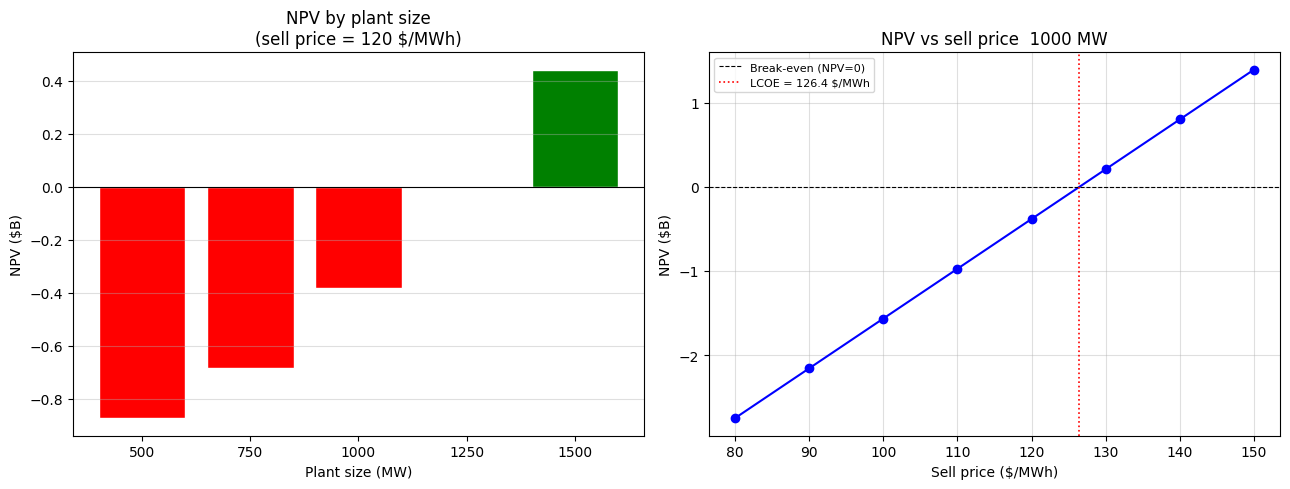

In [21]:
# ── NPV vs sell price at a fixed plant size ───────────────────────────────────
fixed_capacity_mw = 1000
fixed_capacity_kw = fixed_capacity_mw * 1000

h2i.prob.set_val('nuclear.system_capacity',   fixed_capacity_kw, units='kW')
h2i.prob.set_val('grid.interconnection_size', fixed_capacity_kw, units='kW')
h2i.prob.set_val('nuclear.electricity_demand', np.full(8760, fixed_capacity_kw), units='kW')
h2i.prob.set_val('grid.electricity_demand',    np.full(8760, 500_000), units='kW')

sell_prices_mwh = [80, 90, 100, 110, 120, 130, 140, 150]
price_sweep = []

for sp_mwh in sell_prices_mwh:
    sp_kwh = sp_mwh / 1000
    h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity',
                     sp_kwh, units='USD/(kW*h)')
    h2i.run()
    npv_b = h2i.prob.get_val('finance_subgroup_nuclear_npv.NPV_electricity', 'USD')[0] / 1e9
    price_sweep.append({'sell_price_$/MWh': sp_mwh, 'npv_$B': npv_b})

df_price = pd.DataFrame(price_sweep)
print(f'\n{fixed_capacity_mw} MW nuclear — NPV vs sell price:')
print(df_price.to_string(index=False))

# ── Quick plots ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: NPV vs plant size
ax = axes[0]
sizes = df_npv['nuclear_mw'].values
npvs  = df_npv['npv_$B'].values
colors = ['green' if v >= 0 else 'red' for v in npvs]
ax.bar(range(len(sizes)), npvs, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(sizes)))
ax.set_xticklabels([f'{int(s)}' for s in sizes])
ax.set_xlabel('Plant size (MW)')
ax.set_ylabel('NPV ($B)')
ax.set_title(f'NPV by plant size\n(sell price = {sell_price_kwh*1000:.0f} $/MWh)')
ax.grid(axis='y', alpha=0.4)

# Right: NPV vs sell price
ax = axes[1]
prices = df_price['sell_price_$/MWh'].values
npvs2  = df_price['npv_$B'].values
ax.plot(prices, npvs2, 'bo-', ms=6)
ax.axhline(0, color='black', lw=0.8, ls='--', label='Break-even (NPV=0)')
# Mark the LCOE
lcoe_ref = df_npv.loc[df_npv['nuclear_mw'] == fixed_capacity_mw, 'lcoe_$/MWh'].values
if len(lcoe_ref):
    ax.axvline(lcoe_ref[0], color='red', lw=1.2, ls=':', label=f'LCOE = {lcoe_ref[0]:.1f} $/MWh')
ax.set_xlabel('Sell price ($/MWh)')
ax.set_ylabel('NPV ($B)')
ax.set_title(f'NPV vs sell price  {fixed_capacity_mw} MW')
ax.legend(fontsize=8)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_data' in recording_options['excludes'].
/Users/svijaysh/Anaconda/anaconda3/envs/h2integrate/lib/python3.11/site-packages/openmdao/core/driver.py:776: OpenMDAOWarning:Driver: No matches for pattern '*resource_

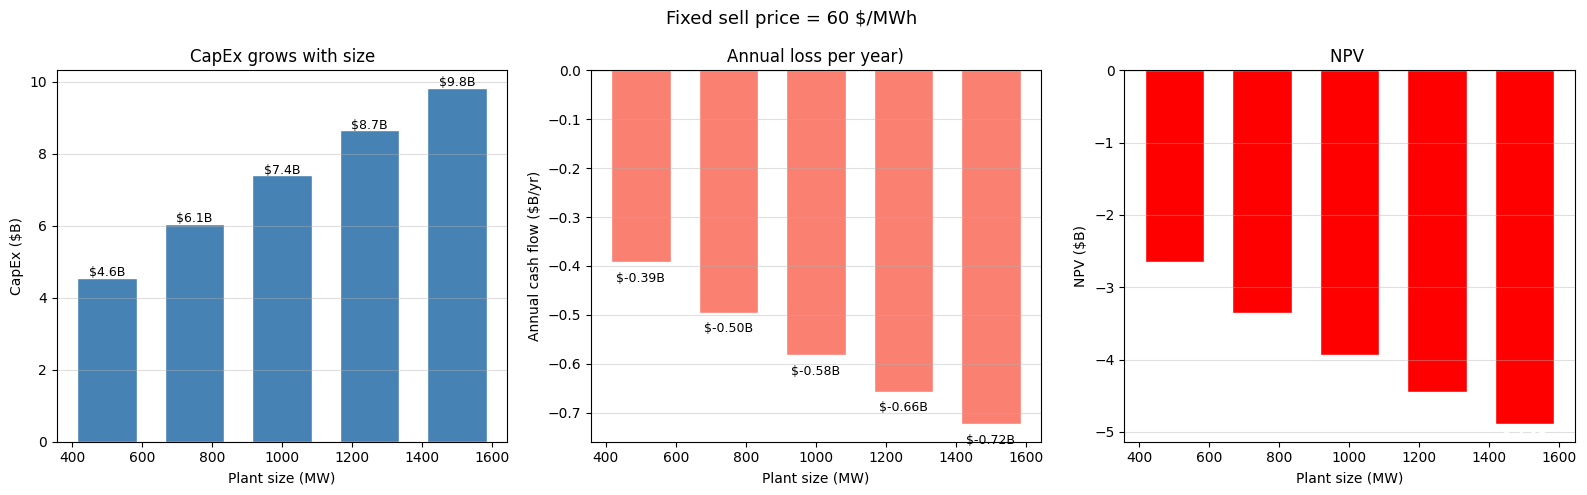


Sell price: 60 $/MWh
    Size         LCOE     Loss/MWh      CapEx     Ann.Loss        NPV
   500 MW     149.5 $/MWh     -89.5 $/MWh  $  4.6B  $ -0.392B/yr  $ -2.65B
   750 MW     135.4 $/MWh     -75.4 $/MWh  $  6.1B  $ -0.496B/yr  $ -3.35B
  1000 MW     126.4 $/MWh     -66.4 $/MWh  $  7.4B  $ -0.582B/yr  $ -3.94B
  1250 MW     120.0 $/MWh     -60.0 $/MWh  $  8.7B  $ -0.657B/yr  $ -4.44B
  1500 MW     115.0 $/MWh     -55.0 $/MWh  $  9.8B  $ -0.723B/yr  $ -4.89B


In [27]:

# ── Why does NPV get MORE negative as plant size grows at a low sell price? ───
# At a fixed low sell price, bigger plant = more CapEx sunk + more annual losses

low_sell_price_mwh = 60   # $/MWh — well below any LCOE

sizes_mw   = [500, 750, 1000, 1250, 1500]
capacity_factors = 0.9    # assumed ~90% CF for nuclear

decomp = []
for capacity_mw in sizes_mw:
    capacity_kw = capacity_mw * 1000

    h2i.prob.set_val('nuclear.system_capacity',    capacity_kw,              units='kW')
    h2i.prob.set_val('grid.interconnection_size',  capacity_kw,              units='kW')
    h2i.prob.set_val('nuclear.electricity_demand', np.full(8760, capacity_kw), units='kW')
    h2i.prob.set_val('grid.electricity_demand',    np.full(8760, 500_000),    units='kW')
    h2i.prob.set_val('finance_subgroup_nuclear_npv.sell_price_electricity',
                     low_sell_price_mwh / 1000, units='USD/(kW*h)')
    h2i.run()

    capex_b      = h2i.prob.get_val('nuclear.CapEx', 'USD')[0] / 1e9
    lcoe_mwh     = h2i.prob.get_val('finance_subgroup_nuclear.LCOE', 'USD/(kW*h)')[0] * 1000
    annual_gwh   = h2i.prob.get_val('nuclear.total_electricity_produced', 'kW*h')[0] / 1e6
    annual_loss_b = (low_sell_price_mwh - lcoe_mwh) * annual_gwh * 1e3 / 1e9  # $B/yr
    npv_b        = h2i.prob.get_val('finance_subgroup_nuclear_npv.NPV_electricity', 'USD')[0] / 1e9

    decomp.append({
        'mw': capacity_mw, 'capex_b': capex_b,
        'lcoe': lcoe_mwh,  'annual_loss_b': annual_loss_b, 'npv_b': npv_b,
    })

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Fixed sell price = {low_sell_price_mwh} $/MWh ',
             fontsize=13, )

mws        = [d['mw']           for d in decomp]
capexs     = [d['capex_b']      for d in decomp]
ann_losses = [d['annual_loss_b'] for d in decomp]
npvs       = [d['npv_b']        for d in decomp]
lcoes      = [d['lcoe']         for d in decomp]

# --- Panel 1: CapEx vs size ---
ax = axes[0]
ax.bar(mws, capexs, width=170, color='steelblue', edgecolor='white')
ax.set_xlabel('Plant size (MW)')
ax.set_ylabel('CapEx ($B)')
ax.set_title('CapEx grows with size')
for i, (mw, v) in enumerate(zip(mws, capexs)):
    ax.text(mw, v + 0.05, f'${v:.1f}B', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.4)

# --- Panel 2: Annual loss vs size ---
ax = axes[1]
ax.bar(mws, ann_losses, width=170, color='salmon', edgecolor='white')
ax.set_xlabel('Plant size (MW)')
ax.set_ylabel('Annual cash flow ($B/yr)')
ax.set_title(f'Annual loss per year)')
for mw, v in zip(mws, ann_losses):
    ax.text(mw, v - 0.02, f'${v:.2f}B', ha='center', va='top', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.grid(axis='y', alpha=0.4)

# --- Panel 3: NPV vs size ---
ax = axes[2]
ax.bar(mws, npvs, width=170, color='red', edgecolor='white')
ax.set_xlabel('Plant size (MW)')
ax.set_ylabel('NPV ($B)')
ax.set_title('NPV ')
for mw, v in zip(mws, npvs):
    ax.text(mw, v - 0.1, f'${v:.1f}B', ha='center', va='top', fontsize=9, color='white', fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nSell price: {low_sell_price_mwh} $/MWh")
print(f"{'Size':>8} {'LCOE':>12} {'Loss/MWh':>12} {'CapEx':>10} {'Ann.Loss':>12} {'NPV':>10}")
for d in decomp:
    loss_per_mwh = low_sell_price_mwh - d['lcoe']
    print(f"{d['mw']:>6} MW  {d['lcoe']:>8.1f} $/MWh  {loss_per_mwh:>8.1f} $/MWh  "
          f"${d['capex_b']:>5.1f}B  ${d['annual_loss_b']:>7.3f}B/yr  ${d['npv_b']:>6.2f}B")


In [2]:
.65**3

0.274625

In [5]:
import math
math.sqrt(.68*(1-.68))

0.466476151587624